# Plotting covariance matrices

This is a notebook in which we can plot the results of our covariance matrix generation, signal-to-noise ratio etc

## 1 Packages <a id='packages'></a>
[Back to content](#content)

In [6]:
# Load packages
%matplotlib inline
import os
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import pickle
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata

# Use TeX
from matplotlib import rc
rc('text', usetex=False)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

## 2 Reading in data 

## 2.1 Reading in distributions

Here, we read in our angular and redshift distributions, which gives us several important parameters we'll need in the plotting

In [2]:
def load_file(filename):
    """Loads a pickled dictionary"""
    with open(filename, "rb") as f:
        data = pickle.load(f)  # Load the dictionary from the pickle file

    return(data)

#the file containing the redshift distributions
redshift_distributions = load_file(f"data/redshift_distributions")

Nbinz_E = redshift_distributions["E"].Nbinz
Nbinz_P = redshift_distributions["P"].Nbinz

Nbinz = {'LP': Nbinz_P,
         'LE': Nbinz_E,
         'LL': 0
        }

#the file containing the angular distributions
angular_distributions = load_file(f"data/angular_distributions")

#LL

Nbina_LL_plus = angular_distributions["LL_plus"].Nbina
Nbina_LL_minus = angular_distributions["LL_minus"].Nbina

Nbina_LL = [angular_distributions["LL_plus"].Nbina + angular_distributions["LL_minus"].Nbina]

#LE

Nbina_LE_plus = []
Nbina_LE_minus = []
Nbina_LE = []

for b in range(Nbinz_E):
    
    Nbina_LE_plus.append(angular_distributions["LE_plus"][b].Nbina)
    Nbina_LE_minus.append(angular_distributions["LE_minus"][b].Nbina)

    Nbina_LE.append(angular_distributions["LE_plus"][b].Nbina + angular_distributions["LE_minus"][b].Nbina)

#LP

Nbina_LP = []

for b in range(Nbinz_P):
    
    Nbina_LP.append(angular_distributions["LP"][b].Nbina)

#dictionaries to store the data

angular_bin_dictionary = {'LL': Nbina_LL,
                          'LE': Nbina_LE,
                          'LP': Nbina_LP
                        }

angular_bin_dictionary_pm = {'LL': {'plus': [Nbina_LL_plus], 'minus': [Nbina_LL_minus]},
                          'LE': {'plus': Nbina_LE_plus, 'minus': Nbina_LE_minus},
                          'LP': Nbina_LP
                        }

### 2.2 Reading in correlations

Here, we read the binned correlation functions, and save them in a dictionary called "correlations_dict". As we are only considering one angular bin, each entry is just a single number, the maximum possible signal when integrating over all redshifts and an optimised angular binning

In [3]:
with open(f'data/binned_correlations/LL', "rb") as f:
    LL = pickle.load(f)

LL_m = LL['minus_correlation'][0]
LL_p = LL['plus_correlation'][0]

file_name = f'data/binned_correlations/LE0'
            
with open(f'data/binned_correlations/LE0', "rb") as f:
    LE = pickle.load(f)

LE_m = LE['minus_correlation'][0]
LE_p = LE['plus_correlation'][0]
            
with open(f'data/binned_correlations/LP0', "rb") as f:
    LP = pickle.load(f)

LP = LP['correlation'][0]
                
    
correlations_dict = {'LLm': LL_m,
                     'LLp': LL_p,
                     'LEm': LE_m,
                     'LEp': LE_p,
                     'LP': LP
}

{'LLm': 8.92566211798468e-06, 'LLp': 4.7759844699456555e-05, 'LEm': 3.8619808962179236e-06, 'LEp': 2.0044899195234493e-05, 'LP': 5.766684212628087e-05}


### 2.3 Reading in cosmic variance

Here, we read in the cosmic variance corresponding to each of the correlation functions. Since this is insensitive to measurement noise and the number of lenses, each are just a single number

In [4]:
covloc = f'data/Covariance'

with open(covloc+'/LLLL/ccov', "rb") as f:
    LL_ccov = pickle.load(f)

LLc_m = LL_ccov[0][0]
LLc_p = LL_ccov[1][1]


with open(covloc+'/LELE/ccov', "rb") as f:
    LE_ccov = pickle.load(f)

LEc_m = LE_ccov[0][0]
LEc_p = LE_ccov[1][1]

with open(covloc+'/LPLP/ccov', "rb") as f:
    LPc = pickle.load(f)

### 2.4 Reading in $L$ and $\langle \eta_\mathrm{LOS} \rangle$ grid

Here, we read in the grid of mean LOS measurement errors $\langle \eta_\mathrm{LOS} \rangle$ and the number of lenses $L$ for which each value of noise and sparsity variance has been calculated

In [ ]:
# Read parameters from params.txt
sigma_L_array = []
Nlens_array = []

with open('params.txt', 'r') as f:
    for line in f:
        parts = line.strip().split()  # Split on any whitespace
        sigma_L_array.append(float(parts[0]))
        Nlens_array.append(int(float(parts[1])))

sigma_L_array = np.array(sigma_L_array)
Nlens_array = np.array(Nlens_array)

print(f"Loaded {len(sigma_L_array)} parameter combinations")

### 2.5 Reading in noise and sparsity variance

Here, we read in the noise and sparsity variance corresponding to each of the correlation functions, and each of the L and $<\eta_\mathrm{LOS}>$ values for which they have been calculated. This is the slowest step

In [7]:
# Initialize arrays for covariance matrices
n_params = len(sigma_L_array)

LLs_m = []
LLs_p = []
LLn_m = []
LLn_p = []
LEs_m = []
LEs_p = []
LEn_m = []
LEn_p = []
LPs = []
LPn = []

# Load covariance files for each parameter combination
for i, (sigma_L, Nlens) in enumerate(zip(sigma_L_array, Nlens_array)):
    base_dir = f'data/covariance/sigma_L={sigma_L}_Nlens={Nlens}'
    
    # Load LLLL
    llll_dir = os.path.join(base_dir, 'LLLL')
    with open(os.path.join(llll_dir, 'scov'), 'rb') as f:
        scov = pickle.load(f)
        LLs_m.append(scov[0][0])
        LLs_p.append(scov[1][1])
    with open(os.path.join(llll_dir, 'ncov'), 'rb') as f:
        ncov = pickle.load(f)
        LLn_m.append(ncov[0][0])
        LLn_p.append(ncov[1][1])
    
    # Load LELE
    lele_dir = os.path.join(base_dir, 'LELE')
    with open(os.path.join(lele_dir, 'scov'), 'rb') as f:
        scov = pickle.load(f)
        LEs_m.append(scov[0][0])
        LEs_p.append(scov[1][1])
    with open(os.path.join(lele_dir, 'ncov'), 'rb') as f:
        ncov = pickle.load(f)
        LEn_m.append(ncov[0][0])
        LEn_p.append(ncov[1][1])
    
    # Load LPLP
    lplp_dir = os.path.join(base_dir, 'LPLP')
    with open(os.path.join(lplp_dir, 'scov'), 'rb') as f:
        LPs.append(pickle.load(f))
    with open(os.path.join(lplp_dir, 'ncov'), 'rb') as f:
        LPn.append(pickle.load(f))

# Convert lists to numpy arrays
LLs_m = np.array(LLs_m)
LLs_p = np.array(LLs_p)
LLn_m = np.array(LLn_m)
LLn_p = np.array(LLn_p)
LEs_m = np.array(LEs_m)
LEs_p = np.array(LEs_p)
LEn_m = np.array(LEn_m)
LEn_p = np.array(LEn_p)
LPs = np.array(LPs)
LPn = np.array(LPn)

variance_dict = {'LLm': [LLc_m, LLs_m, LLn_m],
                 'LLp': [LLc_p, LLs_p, LLn_p],
                 'LEm': [LEc_m, LEs_m, LEn_m],
                 'LEp': [LEc_p, LEs_p, LEn_p],
                 'LP': [LPc, LPs, LPn]
}


Loaded 8100 parameter combinations


In [8]:
titles = {'LLm': 'LL minus',
                 'LLp': 'LL plus',
                 'LEm': 'LE minus',
                 'LEp': 'LE plus',
                 'LP': 'LP'
}

In [27]:
def format_sci(value):
    """Format a number in scientific notation."""
    if value == 0:
        return "0"
    exp = int(np.floor(np.log10(abs(value))))
    x = value / 10**exp
    return f"{int(x)}e{exp}"

def plot_SNR_grid(correlation, relative=True, colours=True, log_scale=True, set_extent = False,
                  figsize=(12, 10), smooth=True, interp_resolution=200, snr_smooth_sigma=1.0):
    """
    A grid of SNR vs sigma_L and Nlens

    Args:
        correlation: str, which correlation function we're interested in
        relative: bool, if True, plots the relative contribution of variance source per pixel
        colours: bool, whether to separate out noise/cosmic/sparsity into colours
        log_scale: bool, if True, plot log10(SNR) (does nothing if relative = True)
        figsize: tuple, figure size
        smooth: bool, whether to interpolate to smooth colours between pixels
        interp_resolution: int, number of points in interpolation grid
        snr_smooth_sigma: float, Gaussian sigma for smoothing SNR contours
    """

    ############################################################################
    ################################ Data setup ################################

    #### Extract data ####
    corr_val = correlations_dict[correlation]        # a constant
    ccov_val = variance_dict[correlation][0]         # a constant
    scov_array = variance_dict[correlation][1]       # an array
    ncov_array = variance_dict[correlation][2]       # an array

    unique_sigma_L = np.unique(sigma_L_array)        # the unique sigma_L values making up the grid
    unique_Nlens = np.unique(Nlens_array)            # the unique Nlens values making up the grid

    # mapping sigma_L and Nlens to indices that can be used to match them to the corresponding noise and sparsity variance 
    param_dict = {(sl, nl): i
                  for i, (sl, nl) in enumerate(zip(sigma_L_array, Nlens_array))}
    
    n_sigma = len(unique_sigma_L) # the number of sigma_L values
    n_nlens = len(unique_Nlens)   # the number of Nlens values

    # Build grids
    ccov_grid = np.full((n_nlens, n_sigma), ccov_val) # a grid with identical ccov values at each point, in the shape of the other grids
    scov_grid = np.zeros_like(ccov_grid) # empty grid for sparsity
    ncov_grid = np.zeros_like(ccov_grid) # empty grid for noise

    # loop through the Nlens values
    for i, nl in enumerate(unique_Nlens):

        # loop through the sigma_L values
        for j, sl in enumerate(unique_sigma_L):

            idx = param_dict[(sl, nl)] # the index of this sl, nl combination

            # place sparsity and noise variance in their correct places on the grid
            scov_grid[i, j] = scov_array[idx].item() 
            ncov_grid[i, j] = ncov_array[idx].item()

    #### Derived quantities ####

    # matrices of the standard deviation (square root of the variance) 
    noise_mat = np.sqrt(ncov_grid)
    cosmic_mat = np.sqrt(ccov_grid)
    sparsity_mat = np.sqrt(scov_grid)

    # Total 1-sigma uncertainty
    totals = np.sqrt(noise_mat**2 + cosmic_mat**2 + sparsity_mat**2)

    if relative or colours: # if we are only interested in the relative contribution, pixel by pixel
        # normalize individual components by the total in that pixel
        noise_mat /= totals
        cosmic_mat /= totals
        sparsity_mat /= totals

    # compute SNR grid
    SNR_grid = corr_val / totals

    # if we want the log of the SNR
    if log_scale: 
        SNR_grid = np.log10(np.maximum(SNR_grid, 1e-30))

    #### Logarithmic axes ####

    # the log values of the unique grid values
    log_sigma_orig = np.log10(unique_sigma_L)
    log_nlens_orig = np.log10(unique_Nlens)

    #### clipping ####

    log_sigma_L_min = xlims[correlation][0]
    log_sigma_L_max = xlims[correlation][1]  
    log_Nlens_min = ylims[correlation][0]
    log_Nlens_max = ylims[correlation][1]

    # masks
    mask_sigma = (log_sigma_orig >= log_sigma_L_min) & (log_sigma_orig <= log_sigma_L_max)
    mask_nlens = (log_nlens_orig >= log_Nlens_min) & (log_nlens_orig <= log_Nlens_max)

    # rescale = 
    
    # crop data
    noise_mat     = noise_mat[mask_nlens][:, mask_sigma]
    cosmic_mat    = cosmic_mat[mask_nlens][:, mask_sigma]
    sparsity_mat  = sparsity_mat[mask_nlens][:, mask_sigma]
    SNR_grid      = SNR_grid[mask_nlens][:, mask_sigma]
    
    # crop axes
    log_sigma_orig = log_sigma_orig[mask_sigma]
    log_nlens_orig = log_nlens_orig[mask_nlens]

    #### Interpolation ####
    
    if smooth:

        # empty lists to hold values for interpolation
        points = []
        v_noise = []
        v_cosmic = []
        v_sparse = []
        v_snr = []

        # loop through the Nlens values (log space)
        for i, log_nl in enumerate(log_nlens_orig):

            # loop through the sl values (log space)
            for j, log_sl in enumerate(log_sigma_orig):

                # populate lists for interpolation
                points.append([log_sl, log_nl])
                v_noise.append(noise_mat[i, j])
                v_cosmic.append(cosmic_mat[i, j])
                v_sparse.append(sparsity_mat[i, j])
                v_snr.append(SNR_grid[i, j])

        # turn lists into arrays
        points = np.array(points)
        v_noise = np.array(v_noise)
        v_cosmic = np.array(v_cosmic)
        v_sparse = np.array(v_sparse)
        v_snr = np.array(v_snr)

        # fine grid for interpolation
        log_sigma_fine = np.linspace(log_sigma_orig.min(), log_sigma_orig.max(), interp_resolution)
        log_nlens_fine = np.linspace(log_nlens_orig.min(), log_nlens_orig.max(), interp_resolution)
        log_sigma_grid, log_nlens_grid = np.meshgrid(log_sigma_fine, log_nlens_fine)

        # Interpolate
        noise_mat = griddata(points, v_noise, (log_sigma_grid, log_nlens_grid), method='cubic', fill_value=0)
        cosmic_mat = griddata(points, v_cosmic, (log_sigma_grid, log_nlens_grid), method='cubic', fill_value=0)
        sparsity_mat = griddata(points, v_sparse, (log_sigma_grid, log_nlens_grid), method='cubic', fill_value=0)

        #grid and interpolation for total snr
        SNR_grid = griddata(points, v_snr, (log_sigma_grid, log_nlens_grid), method='cubic', fill_value=np.nan)
        SNR_grid = np.nan_to_num(SNR_grid, nan=np.nanmin(SNR_grid))
            
        # Gaussian smoothing
        SNR_grid = gaussian_filter(SNR_grid, sigma=snr_smooth_sigma)

        # Renormalize relative contributions
        if relative:
            tot_interp = np.sqrt(noise_mat**2 + cosmic_mat**2 + sparsity_mat**2)
            noise_mat /= tot_interp
            cosmic_mat /= tot_interp
            sparsity_mat /= tot_interp

        # the upper and lower bounds of each axis in the interpolated grid
        original_extent = [log_sigma_fine.min(), log_sigma_fine.max(),
                  log_nlens_fine.min(), log_nlens_fine.max()]

        # the values we'll use for the plot if we've interpolated
        sigma_plot, nlens_plot = log_sigma_grid, log_nlens_grid

    else: #if we're not interpolating,
        
        # the upper and lower bounds of each axis in the course grid
        original_extent = [log_sigma_orig.min(), log_sigma_orig.max(),
                  log_nlens_orig.min(), log_nlens_orig.max()]

        # the values we'll use for the plot if we haven't interpolated
        sigma_plot, nlens_plot = np.meshgrid(log_sigma_orig, log_nlens_orig)

    extent = original_extent

    ##############################################################################
    ################################## Plotting ##################################

    # setting up the figure
    fig, ax = plt.subplots(figsize=figsize)
    
    if relative or colours: # if the components will be separated in our final plot
        if relative: # if we're only plotting the relative contributions in each pixel
            
            # RGB relative fractions
            rgb = np.zeros(noise_mat.shape + (3,)) # an rgb matrix to hold our data
            rgb[..., 0] = cosmic_mat # red is cosmic 
            rgb[..., 1] = noise_mat # green is noise
            rgb[..., 2] = sparsity_mat #blue is sparsity
            rgb = np.clip(rgb, 0, 1) #each component should already lie between 0 and 1, but this makes sure

            #plot the RGB matrix
            ax.imshow(rgb, extent=extent, origin='lower', aspect='auto')
            
        else:
            # brightness based on SNR
            if log_scale:
                snr_intensity = (SNR_grid - np.nanmin(SNR_grid)) / (np.nanmax(SNR_grid) - np.nanmin(SNR_grid))
            else:
                snr_intensity = SNR_grid / np.nanmax(SNR_grid)

            #the components of our RGB matrix are the colours x the snr intensity
            rgb = np.zeros(noise_mat.shape + (3,))
            rgb[..., 0] = cosmic_mat * snr_intensity
            rgb[..., 1] = noise_mat  * snr_intensity
            rgb[..., 2] = sparsity_mat * snr_intensity
            rgb = np.clip(rgb, 0, 1)

            ax.imshow(rgb, extent=extent, origin='lower', aspect='auto')

    else:
        # Heatmap of SNR
        im = ax.imshow(SNR_grid, extent=extent, origin='lower', aspect='auto', cmap='inferno_r')
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("log10(SNR)" if log_scale else "SNR")

    # contours
    # contour_levels_lin = np.logspace(-1.4, 1.4, 11)
    contour_levels_lin = np.array([1, 30]) #with a dotted line
    contour_levels_lin1 = np.array([5]) #with a solid line
    contour_levels_log = np.log10(contour_levels_lin)
    contour_levels_log1 = np.log10(contour_levels_lin1)
    
    # Choose which to plot
    levels = contour_levels_log if log_scale else contour_levels_lin
    levels1 = contour_levels_log1 if log_scale else contour_levels_lin1

    #plot the dashed contours
    CS = ax.contour(
        sigma_plot,
        nlens_plot,
        SNR_grid,
        levels=levels,
        colors='white',
        linewidths=1.2,
        linestyles='dashed'
    )

    #plot the solid contours
    CS1 = ax.contour(
        sigma_plot,
        nlens_plot,
        SNR_grid,
        levels=levels1,
        colors='white',
        linewidths=1.2,
        linestyles='solid'
    )
    
    # Format labels
    fmt = {lvl: f"{s:.0f}$\sigma$" for s, lvl in zip(contour_levels_lin, contour_levels_log)}
    fmt1 = {lvl: f"{s:.0f}$\sigma$" for s, lvl in zip(contour_levels_lin1, contour_levels_log1)}
    
    # Use fmt dict in clabel
    ax.clabel(CS, inline=True, fontsize=17, fmt=fmt)
    ax.clabel(CS1, inline=True, fontsize=17, fmt=fmt1)

    #### Axis labels, ticks ####
    
    ax.set_xlabel(r'mean $\gamma_\mathrm{LOS}$ measurement noise $\langle \eta_\mathrm{LOS} \rangle$', fontsize=18)
    ax.set_ylabel(r'number of lenses $L$', fontsize=18)
    ax.set_title(titles[correlation], fontsize=18)

    xticks = np.arange(np.ceil(extent[0]), np.floor(extent[1])+1)
    yticks = np.arange(np.ceil(extent[2]), np.floor(extent[3])+1)

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.set_xticklabels([format_sci(10**v) for v in xticks])
    ax.set_yticklabels([format_sci(10**v) for v in yticks])

    # points to mark
    points_sigma = [0.05, 0.1]      # σ_L values
    points_nlens = [100000, 10000]       # N_lens values
    labels = ["optimistic", "conservative"]             # labels

    #adjusting the positioning of the point labels
    offsets = {
        "optimistic": ooffset[correlation],
        "conservative": coffset[correlation]
        }
    
    # Convert to log scale
    log_points_sigma = np.log10(points_sigma)
    log_points_nlens = np.log10(points_nlens)
    
    # Plot points
    ax.scatter(log_points_sigma, log_points_nlens, marker = 'x', color='white', s=50, zorder=5)
    
    # Add labels
    for x, y, lab in zip(log_points_sigma, log_points_nlens, labels):
        dx, dy = offsets[lab]
        ax.text(x + dx, y + dy, lab,
                color='white', fontsize=12,
                ha='left', va='bottom', zorder=6)

    #annotating regions
    ax.text(xtext[correlation][0], ytext[correlation][0], "noise \ndominated",
            transform=ax.transAxes,
             ha='center', va='bottom', color = 'w',
             fontsize=18)
    ax.text(xtext[correlation][1], ytext[correlation][1], "sparsity \ndominated",
            transform=ax.transAxes,
             ha='center', va='bottom', color = 'w',
             fontsize=18)
    ax.text(xtext[correlation][2], ytext[correlation][2], "cosmic \ndominated",
            transform=ax.transAxes,
             ha='center', va='bottom', color = 'w',
             fontsize=18)
    plt.grid()

    # plt.tight_layout()
    plt.savefig(f'SNR_grid_{correlation}.pdf')
    plt.show()

In [28]:
xlims = {'LLm': (-2.5,0.5),
                 'LLp': (-2.5,0.5),
                 'LEm': (-2.5,0.5),
                 'LEp': (-2.5,0.5),
                 'LP': (-2.5,0.5)
}
ylims = {'LLm': (2.5,7.2),
                 'LLp': (2.5,7.2),
                 'LEm': (1,7),
                 'LEp': (1,7),
                 'LP': (1,7)
}

#noise, sparsity, cosmic labels
xtext = {'LLm': (0.75, 0.24, 0.28),
                 'LLp': (0.75, 0.24, 0.28),
                 'LEm': (0.75, 0.24, 0.32),
                 'LEp': (0.75, 0.24, 0.32),
                 'LP': (0.75, 0.24, 0.32)
}

ytext = {'LLm': (0.4, 0.1, 0.85),
                 'LLp': (0.4, 0.1, 0.85),
                 'LEm': (0.05, 0.2, 0.87),
                 'LEp': (0.05, 0.2, 0.87),
                 'LP': (0.05, 0.2, 0.87)
}

#point label offsets (x,y)
coffset = {'LLm': (0.02, -0.17),
                 'LLp': (0.02, -0.17),
                 'LEm': (-0.35, 0.08),
                 'LEp': (-0.35, 0.08),
                 'LP': (-0.35, 0.08)
}

ooffset = {'LLm': (-0.18, 0.09),
                 'LLp': (-0.18, 0.09),
                 'LEm': (-0.18, 0.09),
                 'LEp': (-0.18, 0.09),
                 'LP': (-0.03, -0.2)
}



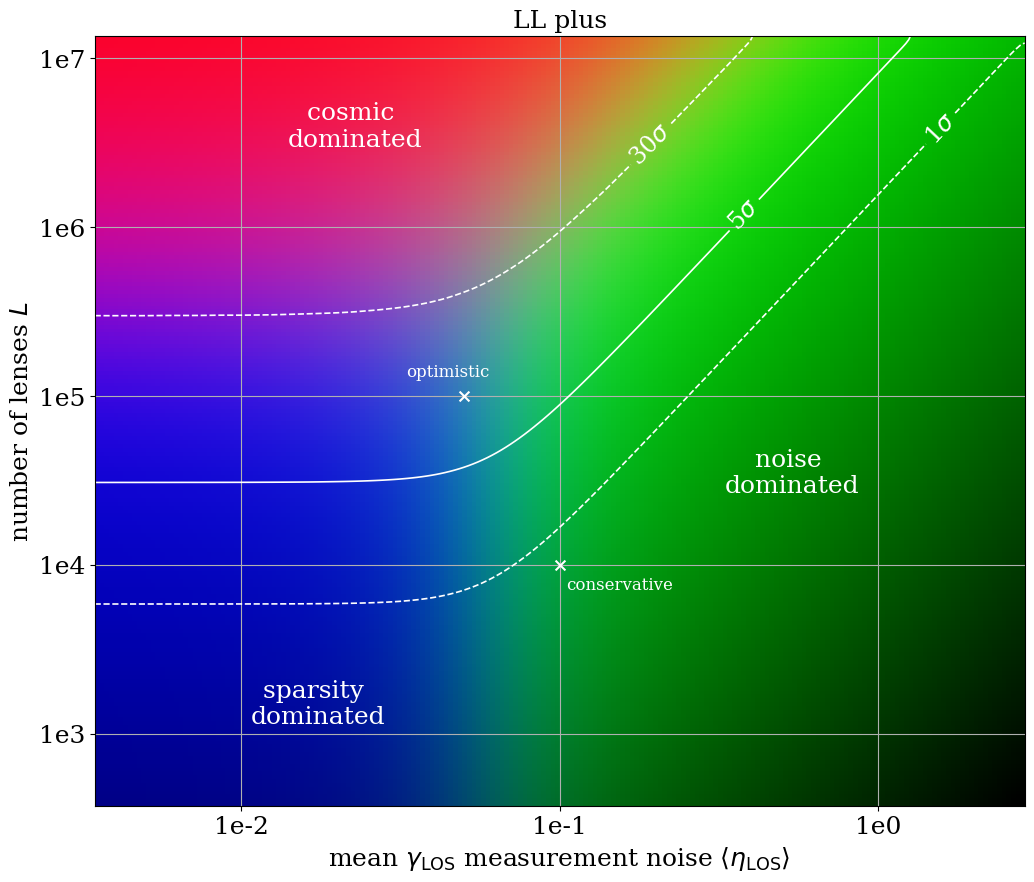

In [29]:
plot_SNR_grid('LLp', relative=False, colours = True, log_scale=True, 
                         set_extent = True, figsize=(12, 10), smooth=True, 
                         interp_resolution=200, snr_smooth_sigma=1.5)